# Compare monocyte annotations across loops

Reads the Loop 3 AnnData and compares CD14/CD16 monocyte annotations (e.g. MCSF vs CD14/CD16) against previous loops.

In [102]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context


from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

## Read anndata

Read the whole AnnData 

In [103]:
adata_loop3 = sc.read_h5ad("../../../project_folder/output/loops/data/loop3/replicate/adata_500k.h5ad")

In [104]:
protocol_columns_loop2 = ['gm-csf_[ng_ml]', 
                            'tpo_[ng_ml]',
                            'sr1_[nm]',
                            'um171_[nm]',
                            'um729_[µm]',
                            'scf_[ng_ml]', 
                            'butyzamide_[nm]', 
                            'retinoic_acid_[µm]',
                            'ldl_[ng_ml]',
                            'il3_[ng_ml]',
                            'il7_[ng_ml]',
                            'o2_[%]', 
                           'days_of_culture', 
                         'experiment_number']

protocol_columns_loop3 = protocol_columns_loop2 + ['ly_cocktail_[ul/well]', 'mcsf_[ng_ml]']

## MCSF vs CD14 and CD16

In [129]:
adata_loop3.obs["CD14"] = adata_loop3[:, "CD14"].X.toarray()
adata_loop3.obs["CD16"] = adata_loop3[:, "CD16"].X.toarray()

# Thresholds
cd14_thr = np.percentile(adata_loop3.obs["CD14"], 75)
cd16_thr = np.percentile(adata_loop3.obs["CD16"], 75)

# Separate AnnData objects
adata_CD14_top = adata_loop3[adata_loop3.obs["CD14"] >= cd14_thr].copy()
adata_CD16_top = adata_loop3[adata_loop3.obs["CD16"] >= cd16_thr].copy()

<Axes: xlabel='mcsf_[ng_ml]', ylabel='CD14'>

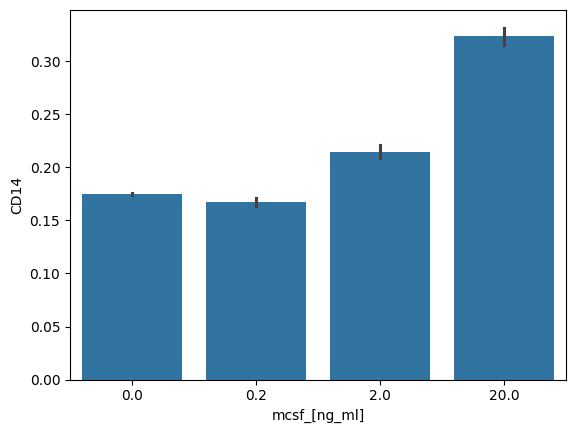

In [141]:
sns.barplot(adata_CD14_top.obs, x='mcsf_[ng_ml]', y="CD14")

<Axes: xlabel='mcsf_[ng_ml]', ylabel='CD16'>

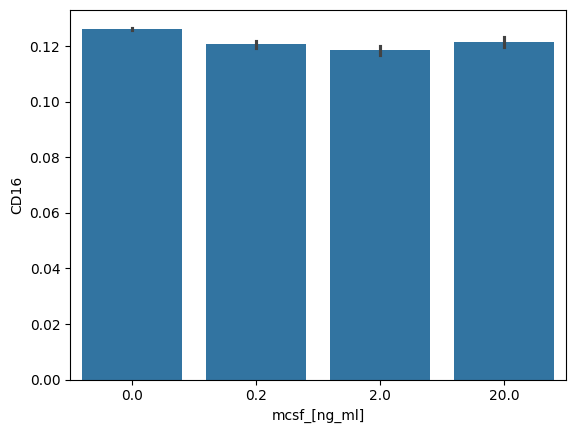

In [142]:
sns.barplot(adata_CD16_top.obs, x='mcsf_[ng_ml]', y="CD16")

Better average across others 

In [188]:
marker_results_cd14 = {"experiment_number": [],
                       "average_cd14": []}

marker_results_cd16 = {"experiment_number": [], 
                       "average_cd16": []}

others_averages_cd14 = []
others_averages_cd16 = []

for experiment_number in np.unique(adata_loop3.obs["experiment_number"]):

    adata_exp = adata_loop3[adata_loop3.obs.experiment_number == experiment_number]

    cd14 = np.asarray(adata_exp[:, "CD14"].X).flatten()
    cd16 = np.asarray(adata_exp[:, "CD16"].X).flatten()

    # 75th percentile thresholds
    cd14_thr = np.percentile(cd14, 75)
    cd16_thr = np.percentile(cd16, 75)

    # Mean of top 25% values
    cd14_mean_top = cd14[cd14 >= cd14_thr].mean()
    cd16_mean_top = cd16[cd16 >= cd16_thr].mean()

    if experiment_number in ["256", "257", "258"]:

        marker_results_cd14["experiment_number"].append(experiment_number)
        marker_results_cd14["average_cd14"].append(cd14_mean_top)

        marker_results_cd16["experiment_number"].append(experiment_number)
        marker_results_cd16["average_cd16"].append(cd16_mean_top)

    else:
        others_averages_cd14.append(cd14_mean_top)
        others_averages_cd16.append(cd16_mean_top)

marker_results_cd14["experiment_number"]  += ["Others" for _ in range(len(others_averages_cd14))]
marker_results_cd14["average_cd14"] += others_averages_cd14

marker_results_cd16["experiment_number"] += (["Others" for _ in range(len(others_averages_cd16))])
marker_results_cd16["average_cd16"] += others_averages_cd16

In [190]:
marker_results_cd14_df = pd.DataFrame(marker_results_cd14)

In [191]:
marker_results_cd16_df = pd.DataFrame(marker_results_cd16)

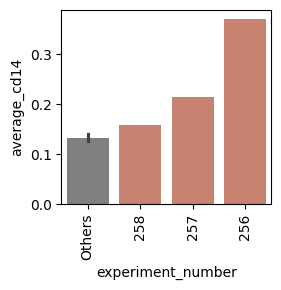

In [192]:
plt.figure(figsize=(3,3))
sns.barplot(
    data=marker_results_cd14_df,
    x="experiment_number",
    y="average_cd14",
    order=["Others", "258", "257", "256"],
    hue="experiment_number",
    palette={"Others": "gray", "258": "#D47A64", "257": "#D47A64", "256": "#D47A64"},
    legend=False
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../plots/cd14_barplot.svg", format="svg")

/tmp/ipykernel_1455197/4123156908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


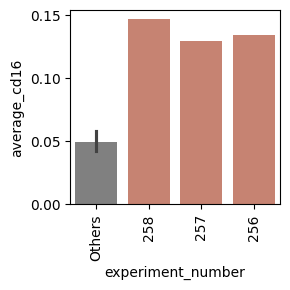

In [193]:
plt.figure(figsize=(3,3))
sns.barplot(
    data=marker_results_cd16_df,
    x="experiment_number",
    y="average_cd16",
    order=["Others", "258", "257", "256"],
    palette={"Others": "gray", "258": "#D47A64", "257": "#D47A64", "256": "#D47A64"}
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../plots/cd16_barplot.svg", format="svg")

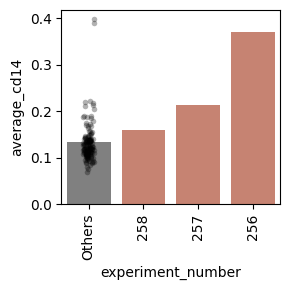

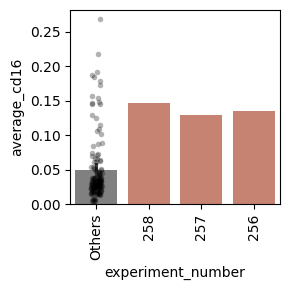

In [203]:
plt.figure(figsize=(3,3))
ax = sns.barplot(
    data=marker_results_cd14_df,
    x="experiment_number",
    y="average_cd14",
    order=["Others", "258", "257", "256"],
    hue="experiment_number",
    palette={"Others": "gray", "258": "#D47A64", "257": "#D47A64", "256": "#D47A64"},
    legend=False
)
# Add stripplot of individual "Others" values
others_df_cd14 = marker_results_cd14_df[marker_results_cd14_df["experiment_number"] == "Others"]
sns.stripplot(
    data=others_df_cd14,
    x="experiment_number",
    y="average_cd14",
    order=["Others", "258", "257", "256"],
    color="black",
    size=4,
    jitter=True,
    alpha=0.3,
    ax=ax
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../plots/cd14_barplot.svg", format="svg")

plt.figure(figsize=(3,3))
ax = sns.barplot(
    data=marker_results_cd16_df,
    x="experiment_number",
    y="average_cd16",
    order=["Others", "258", "257", "256"],
    hue="experiment_number",
    palette={"Others": "gray", "258": "#D47A64", "257": "#D47A64", "256": "#D47A64"},
    legend=False
)
# Add stripplot of individual "Others" values
others_df_cd16 = marker_results_cd16_df[marker_results_cd16_df["experiment_number"] == "Others"]
sns.stripplot(
    data=others_df_cd16,
    x="experiment_number",
    y="average_cd16",
    order=["Others", "258", "257", "256"],
    color="black",
    size=4,
    jitter=True,
    alpha=0.3,
    ax=ax
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../plots/cd16_barplot.svg", format="svg")